# 02 · Classification — UCI HAR (6 activities)

**목표:** 스마트폰 가속도/자이로 9채널 시계열로부터 6가지 활동 분류.

**비교 모델**
1. RandomForest — 561 handcrafted features
2. XGBoost — 561 handcrafted features
3. 1D-CNN — 9채널 × 128 timestep raw 신호 (PyTorch GPU)

**평가 지표:** Accuracy, macro-F1, per-class report, confusion matrix

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from src import data_loader, preprocessing, models_baseline, models_dl, train, evaluate, visualize

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
DEVICE = train.get_device()
print('Device:', DEVICE)

Device: cuda


## 1. 데이터 로드

In [2]:
har = data_loader.load_uci_har()
label_names = har['label_names']
channel_names = har['channel_names']

X_signals_tr = har['X_signals_train']  # (N, 128, 9)
X_signals_te = har['X_signals_test']
X_feat_tr    = har['X_features_train'] # (N, 561)
X_feat_te    = har['X_features_test']
y_tr         = har['y_train']
y_te         = har['y_test']

# zero-index labels for sklearn/torch
y_tr0 = y_tr - 1
y_te0 = y_te - 1
label_names0 = {i - 1: v for i, v in label_names.items()}
print('signals train:', X_signals_tr.shape, ' features train:', X_feat_tr.shape)
print('signals test :', X_signals_te.shape, ' features test :', X_feat_te.shape)

signals train: (7352, 128, 9)  features train: (7352, 561)
signals test : (2947, 128, 9)  features test : (2947, 561)


## 2. RandomForest baseline (handcrafted features)

In [3]:
rf = models_baseline.fit_random_forest(X_feat_tr, y_tr0, n_estimators=300)
rf_pred = rf.predict(X_feat_te)
rf_summary = evaluate.classification_summary(y_te0, rf_pred, label_names=label_names0)
print('Accuracy :', round(rf_summary['accuracy'], 4))
print('Macro-F1 :', round(rf_summary['macro_f1'], 4))
print(rf_summary['report'])

Accuracy : 0.9287
Macro-F1 : 0.9271
                    precision    recall  f1-score   support

           WALKING      0.900     0.976     0.936       496
  WALKING_UPSTAIRS      0.904     0.915     0.909       471
WALKING_DOWNSTAIRS      0.968     0.857     0.909       420
           SITTING      0.912     0.886     0.899       491
          STANDING      0.897     0.921     0.909       532
            LAYING      1.000     1.000     1.000       537

          accuracy                          0.929      2947
         macro avg      0.930     0.926     0.927      2947
      weighted avg      0.930     0.929     0.929      2947



## 3. XGBoost baseline (handcrafted features)

In [4]:
xgb_clf = models_baseline.fit_xgb_classifier(X_feat_tr, y_tr0, n_classes=6, n_estimators=400)
xgb_pred = xgb_clf.predict(X_feat_te)
xgb_summary = evaluate.classification_summary(y_te0, xgb_pred, label_names=label_names0)
print('Accuracy :', round(xgb_summary['accuracy'], 4))
print('Macro-F1 :', round(xgb_summary['macro_f1'], 4))
print(xgb_summary['report'])

Accuracy : 0.9382
Macro-F1 : 0.9373
                    precision    recall  f1-score   support

           WALKING      0.922     0.980     0.950       496
  WALKING_UPSTAIRS      0.928     0.924     0.926       471
WALKING_DOWNSTAIRS      0.970     0.910     0.939       420
           SITTING      0.938     0.857     0.896       491
          STANDING      0.883     0.947     0.914       532
            LAYING      1.000     1.000     1.000       537

          accuracy                          0.938      2947
         macro avg      0.940     0.936     0.937      2947
      weighted avg      0.939     0.938     0.938      2947



## 4. 1D-CNN (PyTorch GPU)

9채널 × 128 timestep raw 신호 직접 입력.

In [5]:
# per-channel normalization (fit on train)
ch_mean = X_signals_tr.mean(axis=(0, 1), keepdims=True)
ch_std  = X_signals_tr.std(axis=(0, 1), keepdims=True) + 1e-8
Xs_tr = (X_signals_tr - ch_mean) / ch_std
Xs_te = (X_signals_te - ch_mean) / ch_std

# split off a small val set from train
rng = np.random.default_rng(42)
perm = rng.permutation(len(Xs_tr))
n_val = int(0.1 * len(Xs_tr))
val_idx, tr_idx = perm[:n_val], perm[n_val:]

tr_loader = train.make_loader(Xs_tr[tr_idx].astype('float32'), y_tr0[tr_idx], batch_size=64, shuffle=True)
va_loader = train.make_loader(Xs_tr[val_idx].astype('float32'), y_tr0[val_idx], batch_size=64, shuffle=False)
te_loader = train.make_loader(Xs_te.astype('float32'), y_te0, batch_size=64, shuffle=False)

In [6]:
cnn = models_dl.CNN1DClassifier(n_channels=9, n_classes=6, hidden=64, dropout=0.3)
history = train.train_model(
    cnn, tr_loader, va_loader,
    loss_fn=torch.nn.CrossEntropyLoss(),
    metric_fn=lambda logits, y: float((logits.argmax(dim=-1) == y).float().mean().item()),
    epochs=15, lr=1e-3,
)

epoch 1/15:   0%|          | 0/104 [00:00<?, ?it/s]

epoch  1: train_loss=0.3573  val_loss=0.1409  val_metric=0.9537


epoch 2/15:   0%|          | 0/104 [00:00<?, ?it/s]

epoch  2: train_loss=0.1488  val_loss=0.1266  val_metric=0.9551


epoch 3/15:   0%|          | 0/104 [00:00<?, ?it/s]

...

epoch 13: train_loss=0.0972  val_loss=0.0851  val_metric=0.9551


epoch 14/15:   0%|          | 0/104 [00:00<?, ?it/s]

epoch 14: train_loss=0.0920  val_loss=0.0874  val_metric=0.9565


epoch 15/15:   0%|          | 0/104 [00:00<?, ?it/s]

epoch 15: train_loss=0.1008  val_loss=0.0929  val_metric=0.9578


In [7]:
cnn_logits = train.predict(cnn, te_loader)
cnn_pred = cnn_logits.argmax(axis=-1)
cnn_summary = evaluate.classification_summary(y_te0, cnn_pred, label_names=label_names0)
print('Accuracy :', round(cnn_summary['accuracy'], 4))
print('Macro-F1 :', round(cnn_summary['macro_f1'], 4))
print(cnn_summary['report'])

Accuracy : 0.9223
Macro-F1 : 0.9221
                    precision    recall  f1-score   support

           WALKING      1.000     0.976     0.988       496
  WALKING_UPSTAIRS      0.957     0.949     0.953       471
WALKING_DOWNSTAIRS      0.913     1.000     0.955       420
           SITTING      0.847     0.741     0.790       491
          STANDING      0.819     0.876     0.847       532
            LAYING      1.000     1.000     1.000       537

          accuracy                          0.922      2947
         macro avg      0.923     0.924     0.922      2947
      weighted avg      0.923     0.922     0.921      2947



## 5. 모델 비교 & 시각화

In [8]:
summary = pd.DataFrame({
    'Accuracy': [rf_summary['accuracy'], xgb_summary['accuracy'], cnn_summary['accuracy']],
    'Macro-F1': [rf_summary['macro_f1'], xgb_summary['macro_f1'], cnn_summary['macro_f1']],
}, index=['RandomForest', 'XGBoost', '1D-CNN'])
summary

,Accuracy,Macro-F1
RandomForest,0.928741,0.927066
XGBoost,0.938242,0.937312
1D-CNN,0.922294,0.922057


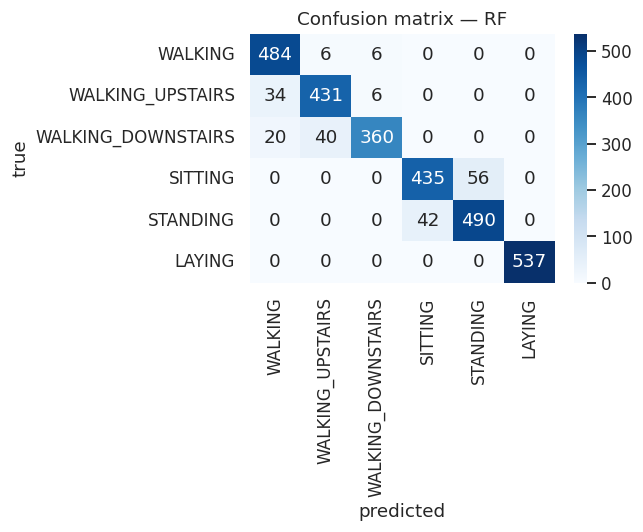

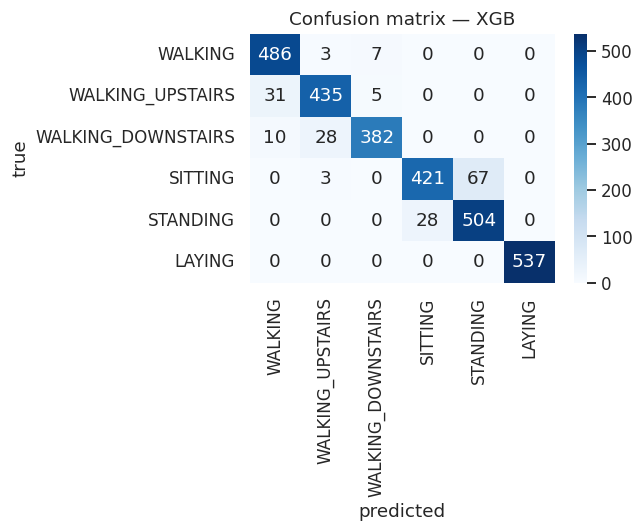

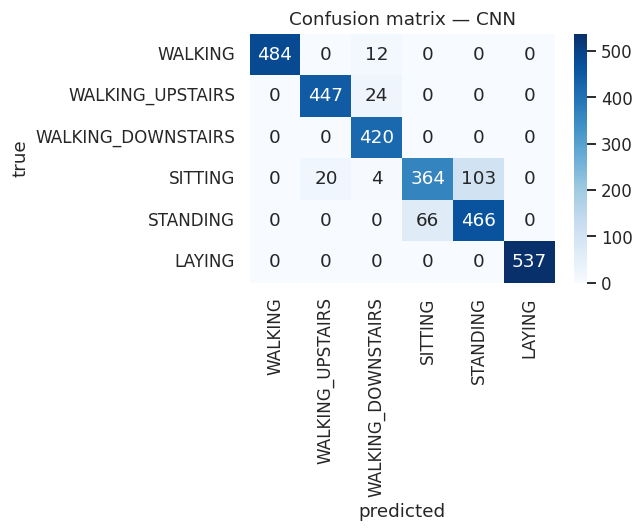

In [9]:
# Confusion matrices (저장)
label_text = [label_names0[i] for i in cnn_summary['labels']]
for name, summ in [('rf', rf_summary), ('xgb', xgb_summary), ('cnn', cnn_summary)]:
    visualize.plot_confusion_matrix(
        summ['confusion_matrix'], label_text,
        title=f'Confusion matrix — {name.upper()}',
        save_as=f'classify_confusion_{name}.png',
    )
plt.show()

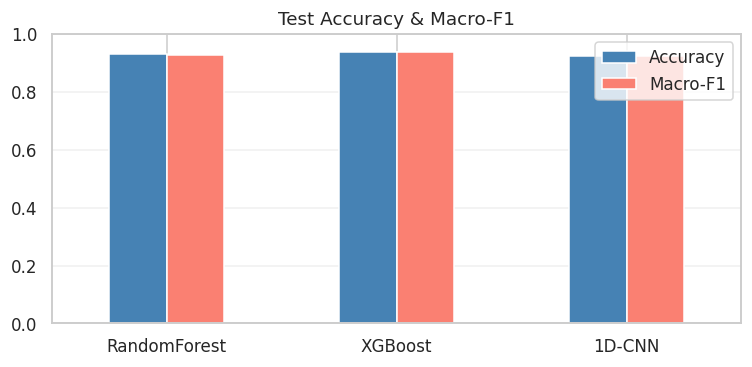

In [10]:
# 모델별 metric bar chart
fig, ax = plt.subplots(figsize=(7, 3.5))
summary.plot(kind='bar', ax=ax, rot=0, color=['steelblue', 'salmon'])
ax.set_ylim(0, 1)
ax.set_title('Test Accuracy & Macro-F1')
ax.grid(alpha=0.3, axis='y')
fig.tight_layout()
fig.savefig(visualize.FIG_DIR / 'classify_metrics_bar.png', dpi=120)
plt.show()

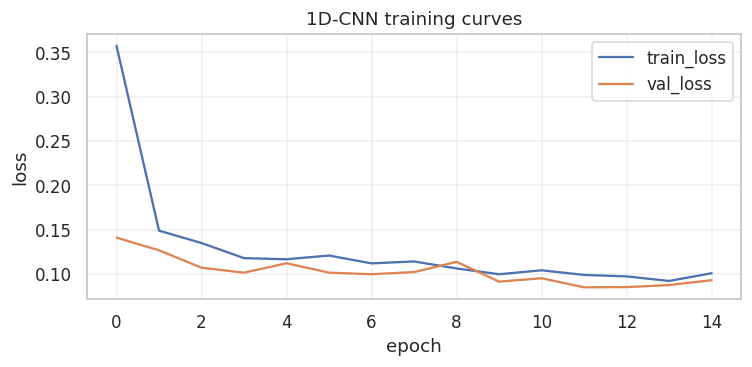

In [11]:
# CNN 학습 곡선
_ = visualize.plot_training_curves(history, title='1D-CNN training curves', save_as='classify_cnn_curves.png')
plt.show()

## 6. 결론

- 561 handcrafted feature + tree 앙상블은 매우 강한 베이스라인 (≥ 92% accuracy 일반적)
- 1D-CNN은 raw 신호만으로도 비슷하거나 더 높은 성능을 달성
- WALKING vs WALKING_UPSTAIRS 같은 유사 활동에서 오분류가 집중되는 경향 확인 → confusion matrix 참고
- 결과 PNG는 `reports/figures/classify_*.png` 에 저장됨